In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
confusion_matrix,
classification_report,
accuracy_score,
roc_auc_score,
roc_curve
)
df=pd.read_csv(r"C:\Users\nirma\OneDrive\Documents\archive (7)\Social_Network_Ads.csv")
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


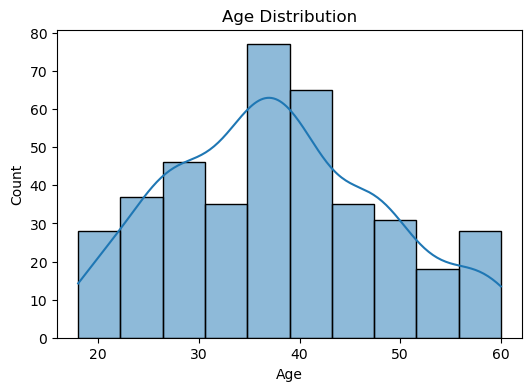

In [3]:
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

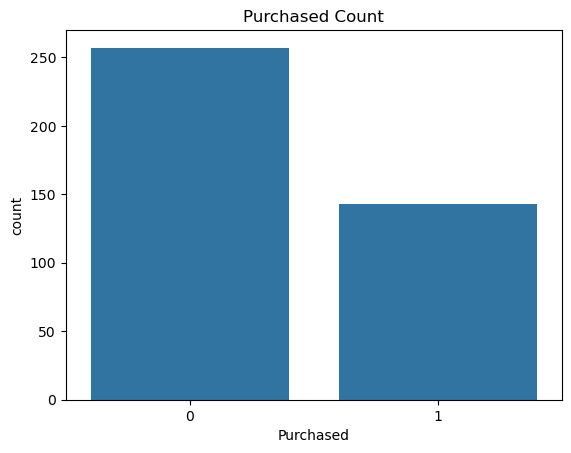

In [4]:
sns.countplot(x='Purchased', data=df)
plt.title("Purchased Count")
plt.show()

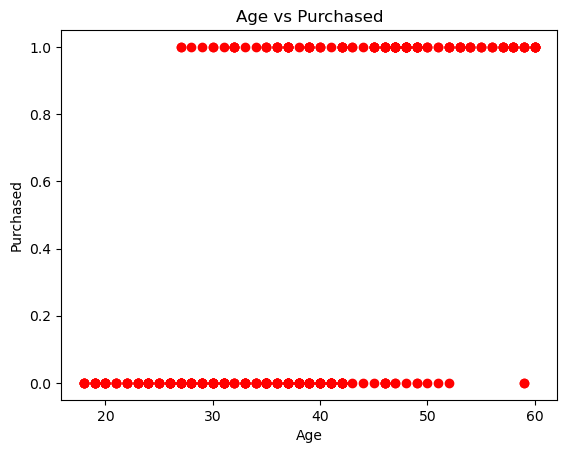

In [5]:
plt.scatter(df['Age'], df['Purchased'], color='red')
plt.xlabel("Age")
plt.ylabel("Purchased")
plt.title("Age vs Purchased")
plt.show()

In [6]:
df['Gender']=df['Gender'].map({"Male":0,"Female":1})

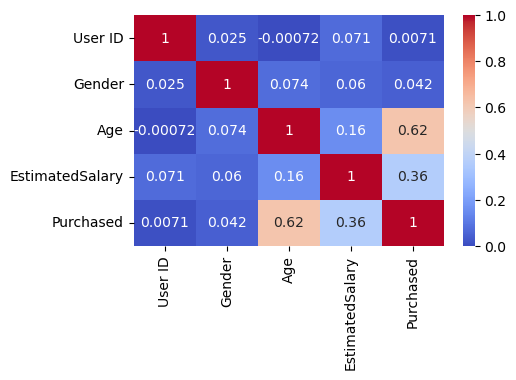

In [7]:
plt.figure(figsize=(5,3))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

In [8]:
df.isnull().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [9]:
X = df[['Age']]
y = df['Purchased']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.1,random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model = LogisticRegression()
model.fit(X_train_scaled, y_train)
LogisticRegression()
y_pred = model.predict(X_test_scaled)
print(y_pred)

[1 1 0 1 0 0 1 0 0 0 0 1 0 0 0 0 1 1 0 1 0 0 1 1 0 1 0 0 1 0 1 0 0 0 0 0 0
 0 0 0]


In [10]:
new_value=pd.DataFrame([[45]],columns=['Age'])
new_value_scaled = scaler.transform(new_value)

prediction = model.predict(new_value_scaled)
probability = model.predict_proba(new_value_scaled)

print("Prediction (0=No, 1=Yes):", prediction)
print("Probability:", probability)

Prediction (0=No, 1=Yes): [1]
Probability: [[0.39557274 0.60442726]]


In [11]:
# Create smooth range
X_range = np.linspace(df['Age'].min(), df['Age'].max(), 300).reshape(-1, 1)

In [12]:
# Convert into DataFrame with correct column name
X_range_df = pd.DataFrame(X_range, columns=['Age'])

In [13]:
# Now scale safely
X_range_scaled = scaler.transform(X_range_df)

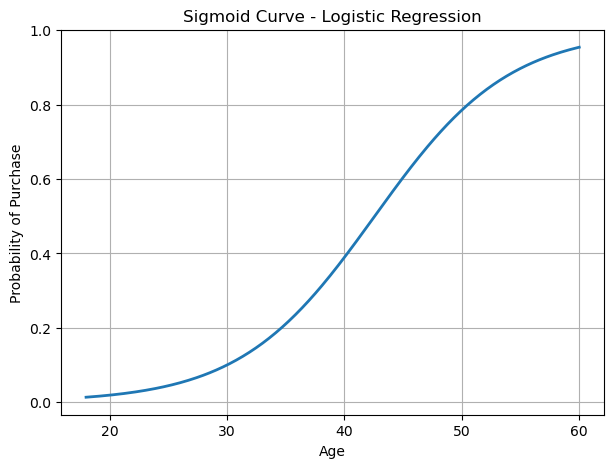

In [14]:
# Predict probabilities
y_range_prob = model.predict_proba(X_range_scaled)[:, 1]
plt.figure(figsize=(7,5))
plt.plot(X_range, y_range_prob, linewidth=2)
plt.xlabel("Age")
plt.ylabel("Probability of Purchase")
plt.title("Sigmoid Curve - Logistic Regression")
plt.grid(True)
plt.show()

In [15]:
plt.figure(figsize=(7,5))

<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

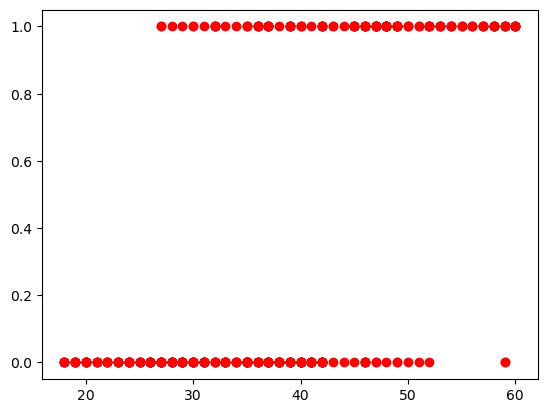

In [16]:
#scatter plot of actual data
plt.scatter(df['Age'],df['Purchased'], color='red',label='ActualData')

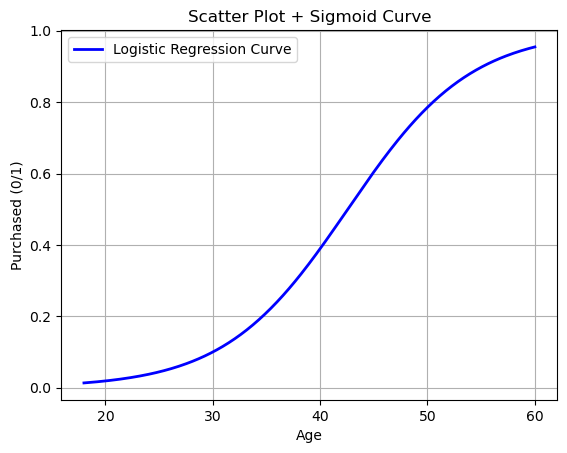

In [17]:
# Sigmoid curve
plt.plot(X_range, y_range_prob, color='blue', linewidth=2,
label='Logistic Regression Curve')
plt.xlabel("Age")
plt.ylabel("Purchased (0/1)")
plt.title("Scatter Plot + Sigmoid Curve")
plt.legend()
plt.grid(True)
plt.show()

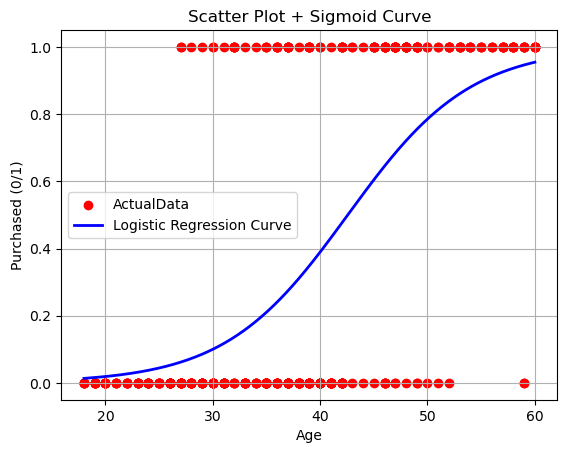

In [18]:
plt.scatter(df['Age'],df['Purchased'], color='red',label='ActualData')
plt.plot(X_range, y_range_prob, color='blue', linewidth=2,
label='Logistic Regression Curve')
plt.xlabel("Age")
plt.ylabel("Purchased (0/1)")
plt.title("Scatter Plot + Sigmoid Curve")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
new_value = pd.DataFrame([[45]], columns=['Age'])
new_scaled = scaler.transform(new_value)
prediction = model.predict(new_scaled)
prob = model.predict_proba(new_scaled)
print(prediction)
print(prob)

[1]
[[0.39557274 0.60442726]]


Accuracy: 0.9


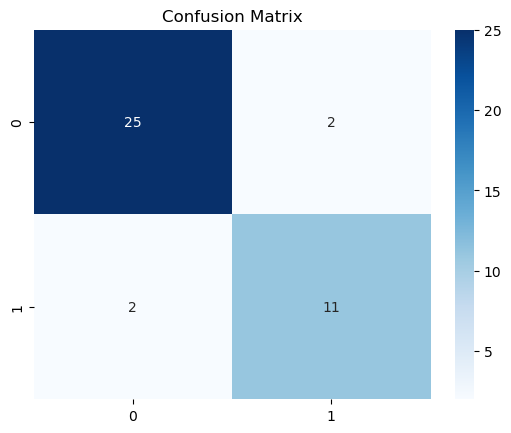

In [20]:
print("Accuracy:", accuracy_score(y_test, y_pred))
Accuracy: 0.64
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [21]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.93      0.93        27
           1       0.85      0.85      0.85        13

    accuracy                           0.90        40
   macro avg       0.89      0.89      0.89        40
weighted avg       0.90      0.90      0.90        40



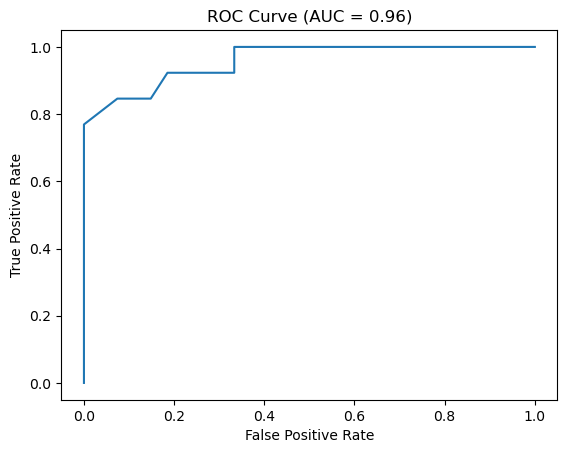

In [22]:
y_prob = model.predict_proba(X_test_scaled)[:,1]
fpr, tpr, threshold = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (AUC = {:.2f})".format(auc))
plt.show()

In [23]:
param_grid = {
'C': [0.01, 0.1, 1, 10, 100],
'solver': ['lbfgs', 'liblinear']
}
grid = GridSearchCV(LogisticRegression(), param_grid, cv=5)
grid.fit(X_train_scaled, y_train)
print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'C': 0.1, 'solver': 'liblinear'}
Best Score: 0.836111111111111


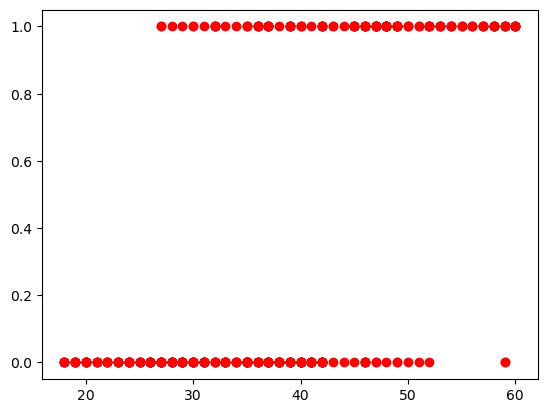

In [24]:
#Actual data (scatter points)
plt.scatter(df['Age'], df['Purchased'], color='red', label='ActualData')

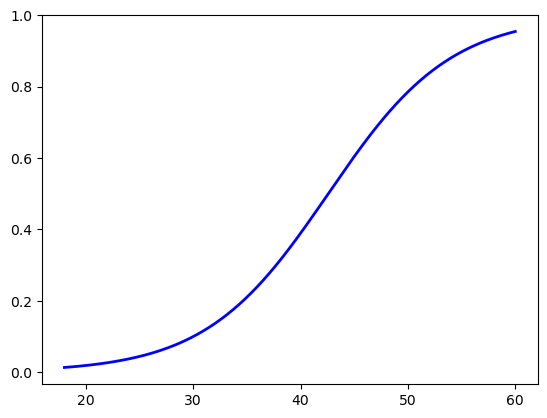

In [25]:
#Sigmoid curve (probability line)
plt.plot(X_range, y_range_prob, color='blue', linewidth=2,
label='Sigmoid Curve')

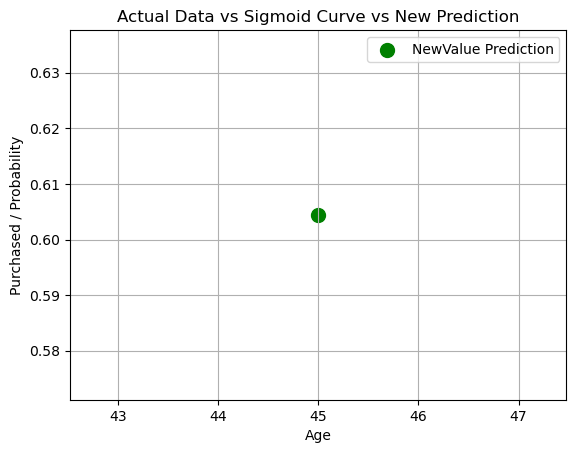

In [26]:
# New value prediction (point on curve)
plt.scatter(new_value, prob[:,1], color='green', s=100, label='NewValue Prediction')
plt.xlabel("Age")
plt.ylabel("Purchased / Probability")
plt.title("Actual Data vs Sigmoid Curve vs New Prediction")
plt.legend()
plt.grid(True)
plt.show()

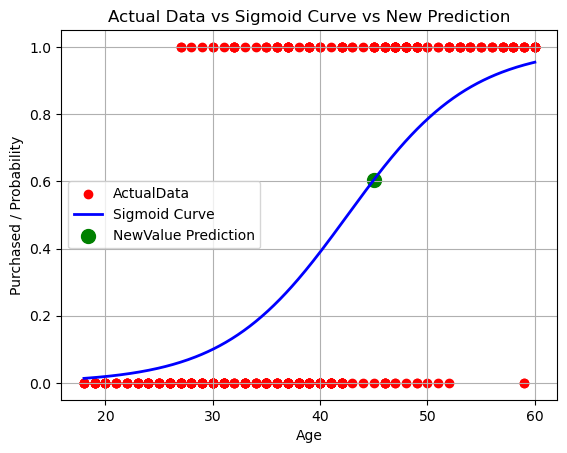

In [27]:
plt.scatter(df['Age'], df['Purchased'], color='red', label='ActualData')
plt.plot(X_range, y_range_prob, color='blue', linewidth=2,
label='Sigmoid Curve')
plt.scatter(new_value, prob[:,1], color='green', s=100, label='NewValue Prediction')
plt.xlabel("Age")
plt.ylabel("Purchased / Probability")
plt.title("Actual Data vs Sigmoid Curve vs New Prediction")
plt.legend()
plt.grid(True)
plt.show()